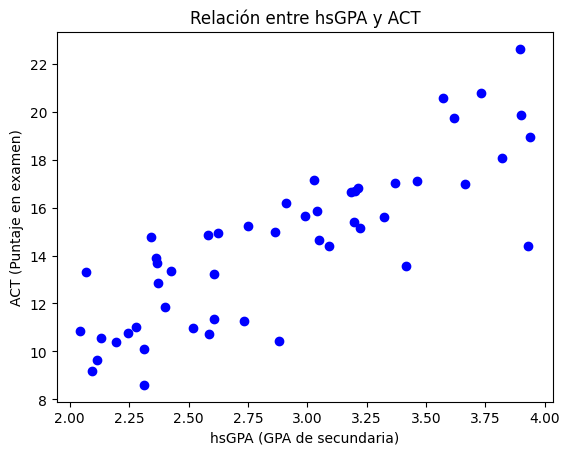

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulación de datos de hsGPA y ACT
np.random.seed(42)
hsGPA = np.random.uniform(2.0, 4.0, 50)  # Notas entre 2.0 y 4.0
ACT = hsGPA * 5 + np.random.normal(0, 2, 50)  # ACT es proporcional a hsGPA

plt.scatter(hsGPA, ACT, color='blue')
plt.xlabel("hsGPA (GPA de secundaria)")
plt.ylabel("ACT (Puntaje en examen)")
plt.title("Relación entre hsGPA y ACT")
plt.show()


In [ ]:
import scipy.stats as stats

# Calcular correlación de Pearson
r, p_value = stats.pearsonr(hsGPA, ACT)

print(f"Coeficiente de correlación de Pearson: {r:.3f}")


Coeficiente de correlación de Pearson: 0.833


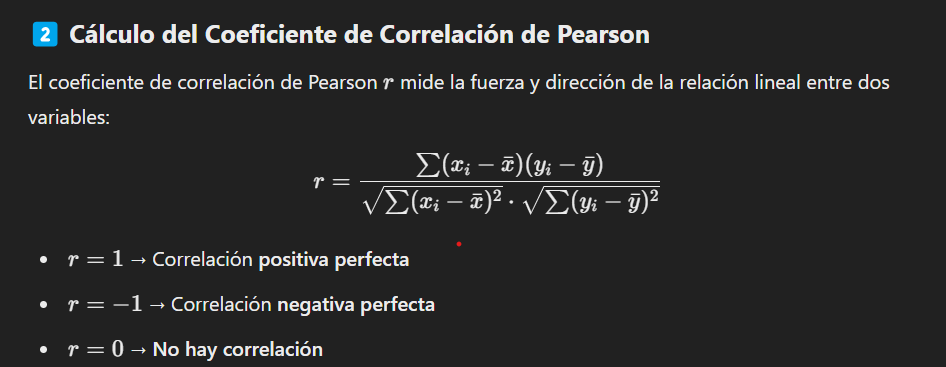

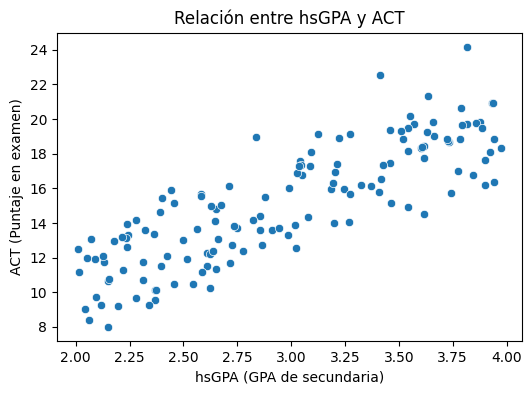

📌 Correlación entre hsGPA y ACT: 0.837

🔹 Regresión Simple: colGPA ~ ACT
                            OLS Regression Results                            
Dep. Variable:                 colGPA   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     140.1
Date:                Mon, 10 Mar 2025   Prob (F-statistic):           8.73e-23
Time:                        23:37:13   Log-Likelihood:                 7.1497
No. Observations:                 141   AIC:                            -10.30
Df Residuals:                     139   BIC:                            -4.402
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr

# 🔹 1. Simulación de datos (basado en el ejemplo de Wooldridge)
np.random.seed(42)

# Creamos datos de GPA secundaria y ACT con correlación
hsGPA = np.random.uniform(2.0, 4.0, 141)  # GPA entre 2.0 y 4.0
ACT = hsGPA * 5 + np.random.normal(0, 2, 141)  # ACT correlacionado con hsGPA

# Generamos el colGPA con la ecuación dada + un término de error aleatorio
colGPA = 1.29 + 0.453 * hsGPA + 0.0094 * ACT + np.random.normal(0, 0.2, 141)

# Convertimos a un DataFrame
data = pd.DataFrame({"hsGPA": hsGPA, "ACT": ACT, "colGPA": colGPA})

# 🔹 2. Visualizar la correlación entre hsGPA y ACT
plt.figure(figsize=(6, 4))
sns.scatterplot(x=hsGPA, y=ACT)
plt.xlabel("hsGPA (GPA de secundaria)")
plt.ylabel("ACT (Puntaje en examen)")
plt.title("Relación entre hsGPA y ACT")
plt.show()

# Calcular coeficiente de correlación entre hsGPA y ACT
corr, _ = pearsonr(hsGPA, ACT)
print(f"📌 Correlación entre hsGPA y ACT: {corr:.3f}")

# 🔹 3. Regresión simple: colGPA ~ ACT
X_simple = sm.add_constant(data["ACT"])  # Agregar constante
modelo_simple = sm.OLS(data["colGPA"], X_simple).fit()
print("\n🔹 Regresión Simple: colGPA ~ ACT")
print(modelo_simple.summary())

# 🔹 4. Regresión múltiple: colGPA ~ hsGPA + ACT
X_multiple = sm.add_constant(data[["hsGPA", "ACT"]])  # Agregar constante
modelo_multiple = sm.OLS(data["colGPA"], X_multiple).fit()
print("\n🔹 Regresión Múltiple: colGPA ~ hsGPA + ACT")
print(modelo_multiple.summary())

# 🔹 5. Comparación de coeficientes
print("\n📌 Comparación de coeficientes:")
print(f"ACT en regresión simple: {modelo_simple.params['ACT']:.4f}")
print(f"ACT en regresión múltiple: {modelo_multiple.params['ACT']:.4f}")


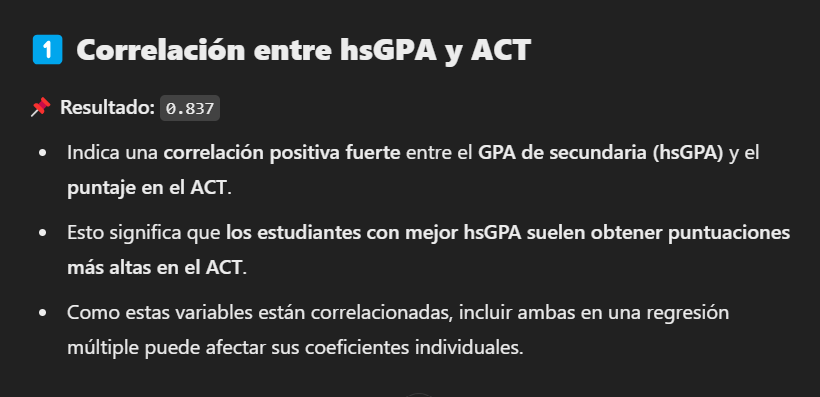

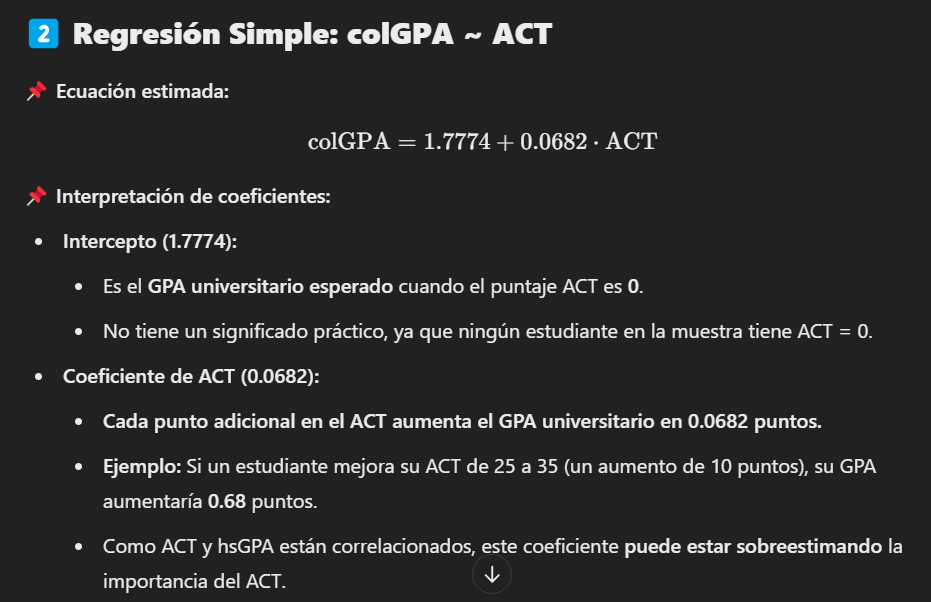



> Add blockquote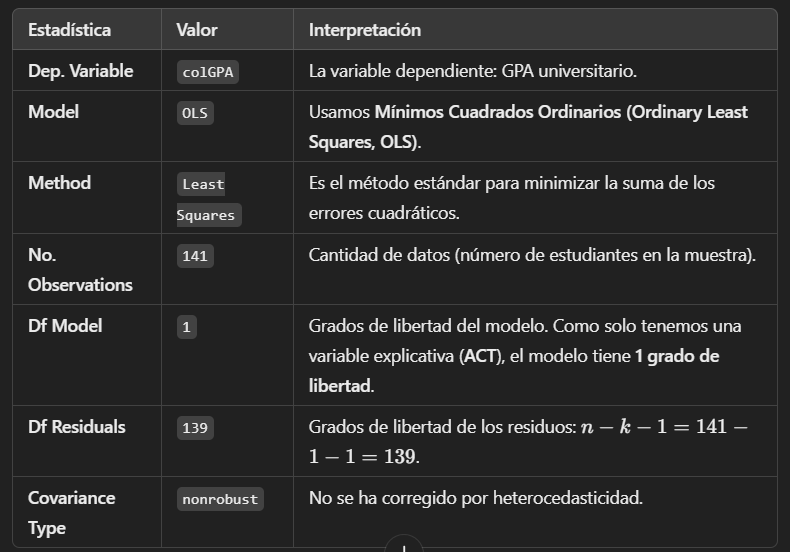



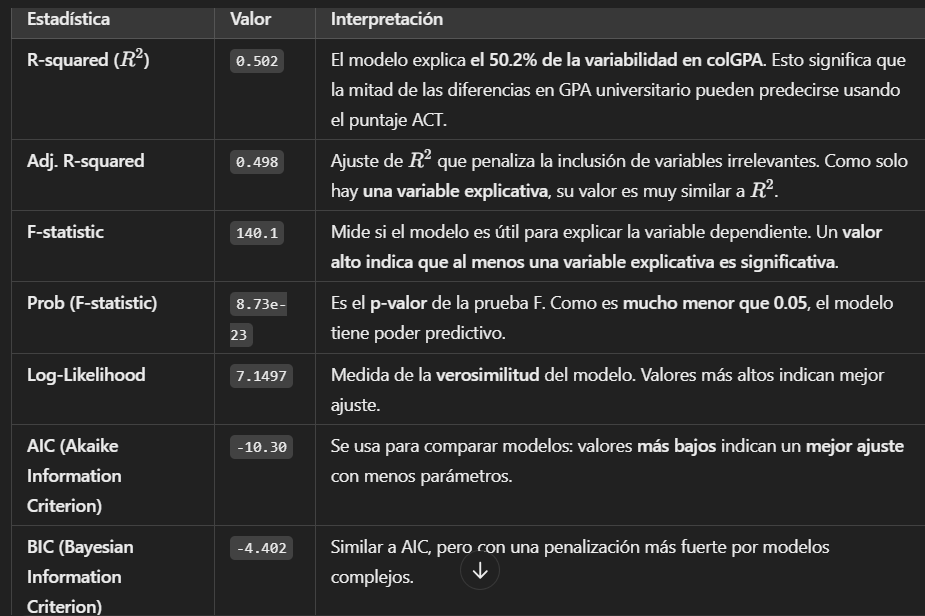

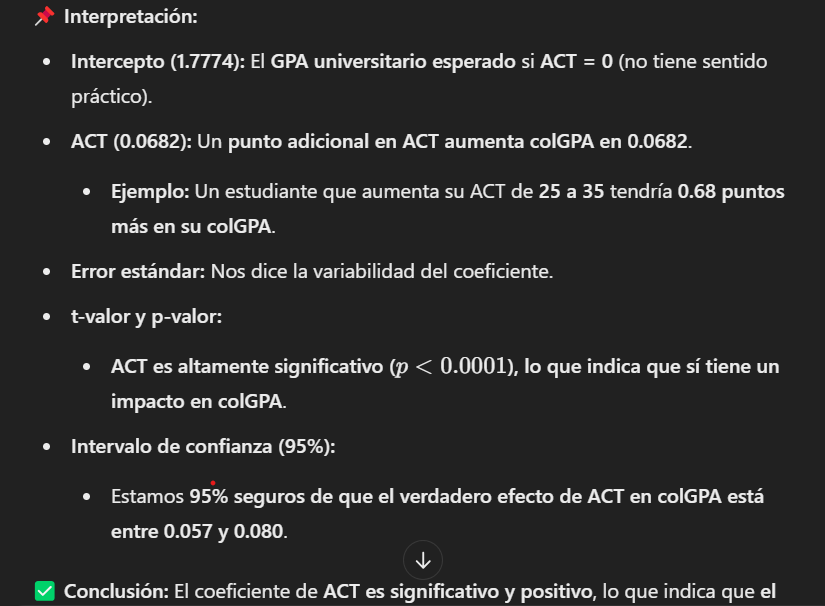

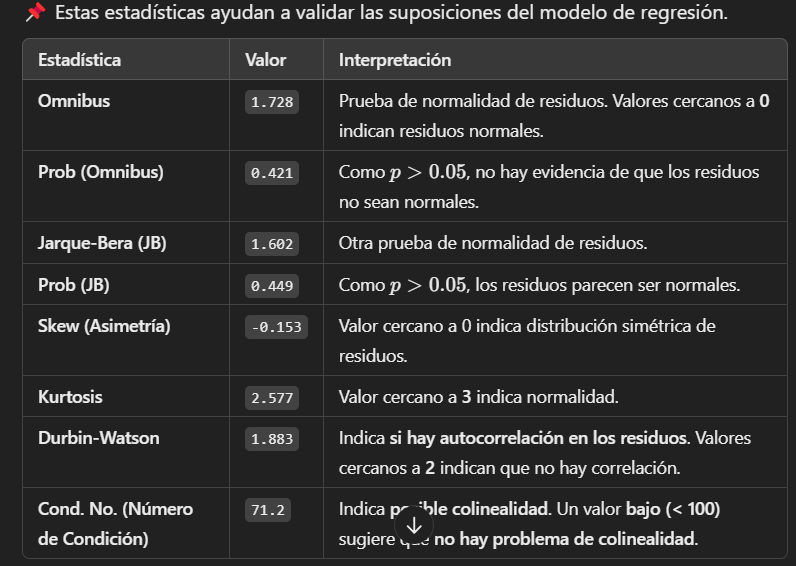

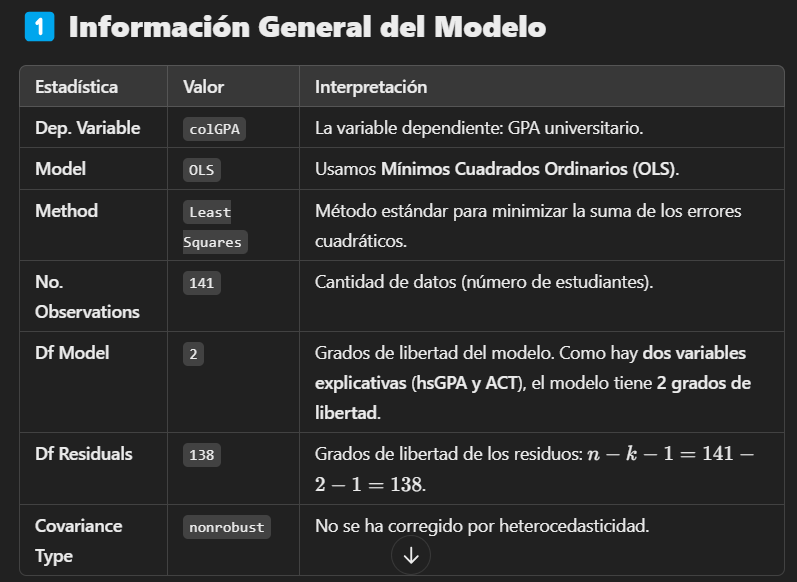

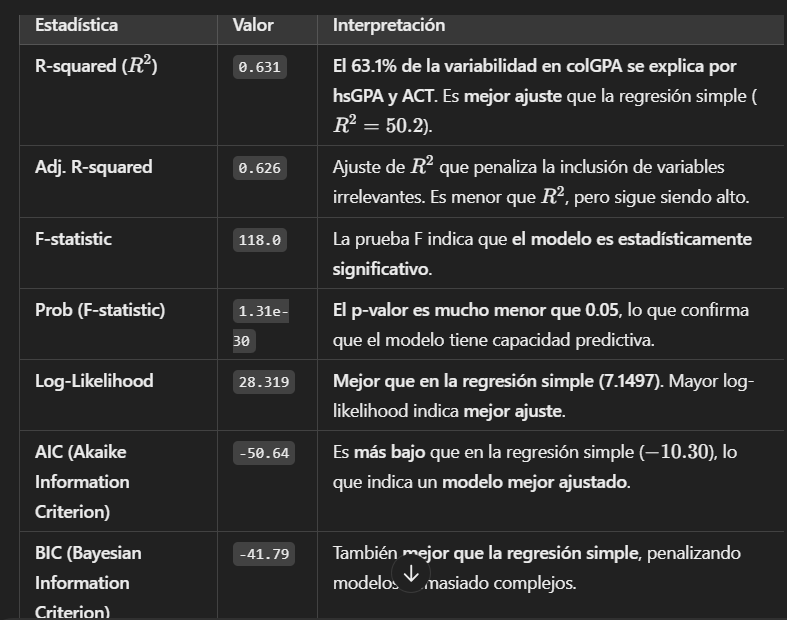

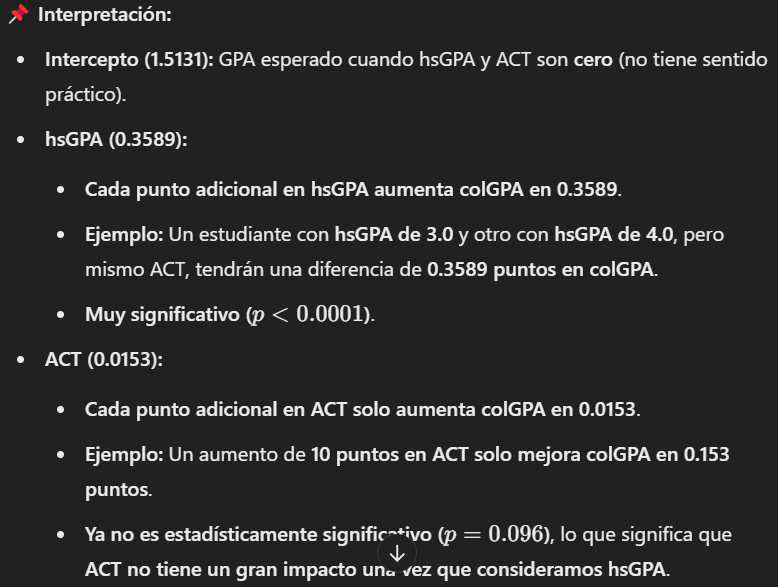

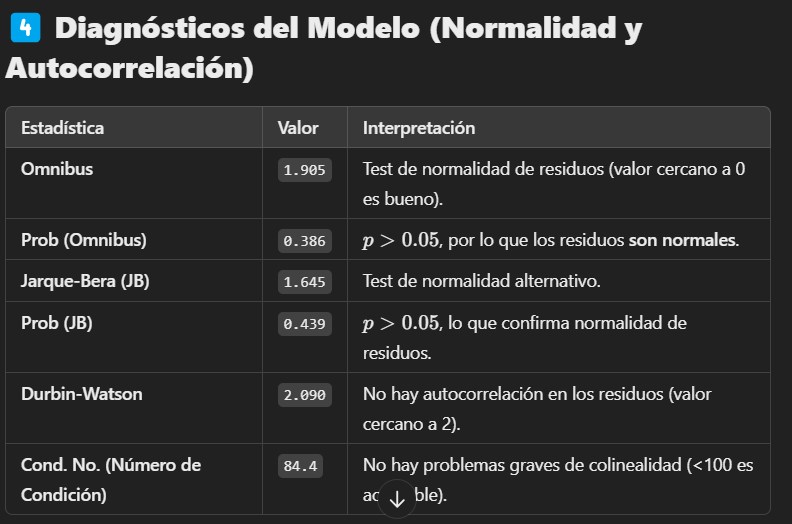

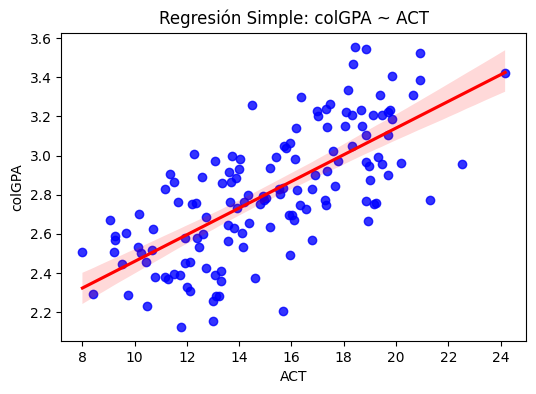

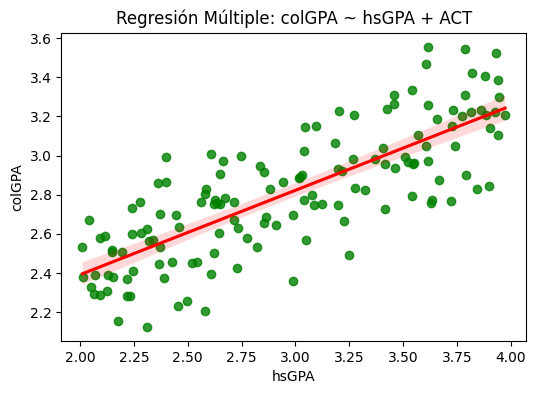

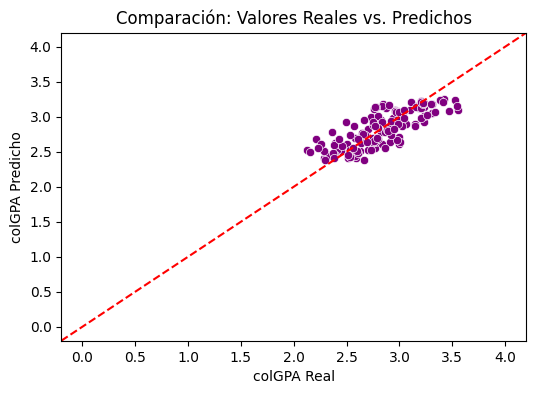

In [ ]:
import seaborn as sns

# 🔹 1. Gráfico de dispersión con la regresión simple (ACT ~ colGPA)
plt.figure(figsize=(6,4))
sns.regplot(x=data["ACT"], y=data["colGPA"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel("ACT")
plt.ylabel("colGPA")
plt.title("Regresión Simple: colGPA ~ ACT")
plt.show()

# 🔹 2. Gráfico de dispersión con la regresión múltiple (hsGPA ~ colGPA)
plt.figure(figsize=(6,4))
sns.regplot(x=data["hsGPA"], y=data["colGPA"], scatter_kws={"color": "green"}, line_kws={"color": "red"})
plt.xlabel("hsGPA")
plt.ylabel("colGPA")
plt.title("Regresión Múltiple: colGPA ~ hsGPA + ACT")
plt.show()

# 🔹 3. Comparación entre valores reales y predichos en la regresión múltiple
data["Predicted_colGPA"] = modelo_multiple.predict(sm.add_constant(data[["hsGPA", "ACT"]]))

plt.figure(figsize=(6,4))
sns.scatterplot(x=data["colGPA"], y=data["Predicted_colGPA"], color="purple")
plt.xlabel("colGPA Real")
plt.ylabel("colGPA Predicho")
plt.title("Comparación: Valores Reales vs. Predichos")
plt.axline([0, 0], [4, 4], color="red", linestyle="--")  # Línea de referencia
plt.show()


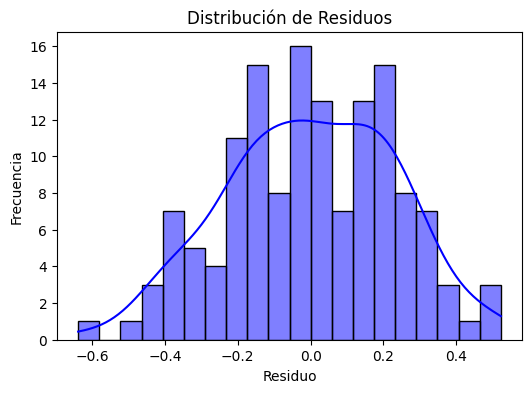

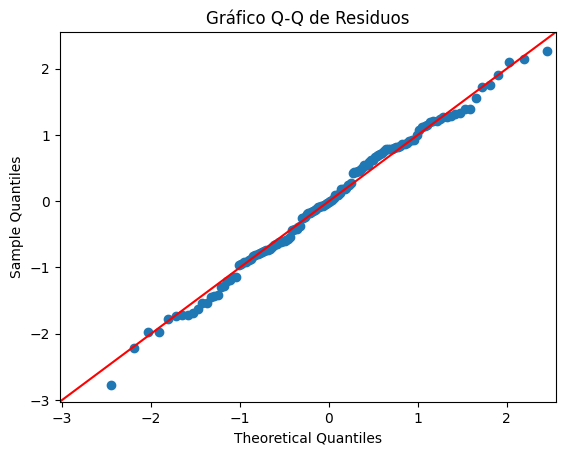

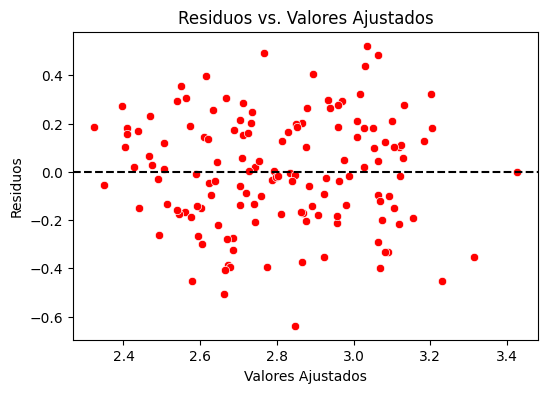

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 🔹 Histograma de residuos
residuos = modelo_simple.resid
plt.figure(figsize=(6,4))
sns.histplot(residuos, bins=20, kde=True, color="blue")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de Residuos")
plt.show()

# 🔹 Gráfico Q-Q para ver normalidad de residuos
sm.qqplot(residuos, line='45', fit=True)
plt.title("Gráfico Q-Q de Residuos")
plt.show()

# 🔹 Gráfico de residuos vs. valores ajustados
plt.figure(figsize=(6,4))
sns.scatterplot(x=modelo_simple.fittedvalues, y=residuos, color="red")
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs. Valores Ajustados")
plt.show()


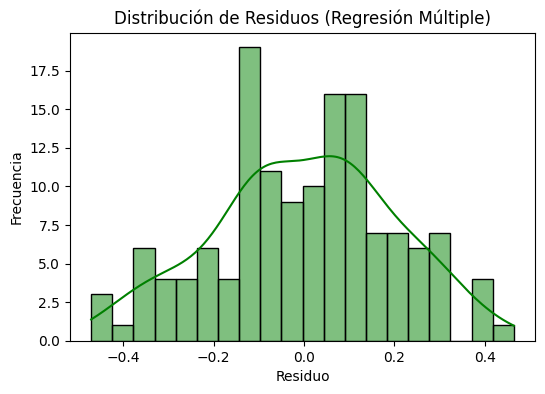

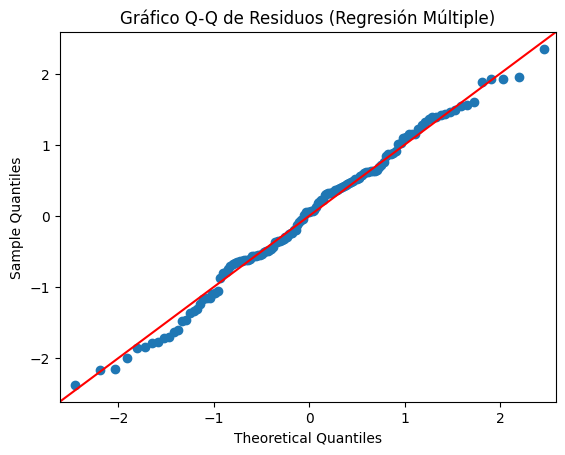

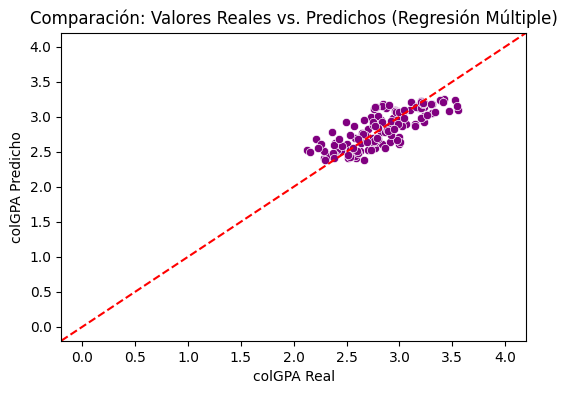

In [ ]:
# 🔹 Histograma de residuos
residuos = modelo_multiple.resid
plt.figure(figsize=(6,4))
sns.histplot(residuos, bins=20, kde=True, color="green")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de Residuos (Regresión Múltiple)")
plt.show()

# 🔹 Gráfico Q-Q para normalidad de residuos
sm.qqplot(residuos, line='45', fit=True)
plt.title("Gráfico Q-Q de Residuos (Regresión Múltiple)")
plt.show()

# 🔹 Comparación valores reales vs. predichos
plt.figure(figsize=(6,4))
sns.scatterplot(x=data["colGPA"], y=modelo_multiple.fittedvalues, color="purple")
plt.xlabel("colGPA Real")
plt.ylabel("colGPA Predicho")
plt.title("Comparación: Valores Reales vs. Predichos (Regresión Múltiple)")
plt.axline([0, 0], [4, 4], color="red", linestyle="--")
plt.show()
